# RiskGuard 🛡️
## Notebook 06: Risk Analysis & Explainable AI (SHAP) — Member 4

**Objective:** Transform raw machine learning predictions into calibrated, actionable project risk assessments and provide rigorous global and local feature attributions using SHAP.

### Notebook Workflow:
1. Ingest champion model, preprocessor, and master dataset
2. Calibrate continuous risk scores: $\text{risk\_score} = \text{delay\_probability} \times 100$
3. Assign discrete risk categories: LOW, MEDIUM, HIGH
4. Analyze portfolio risk distribution
5. Initialize SHAP TreeExplainer for XGBoost
6. Global feature attribution (Beeswarm summary & mean absolute SHAP)
7. Model native feature importance comparison
8. Individual project explanation (positive vs. negative risk drivers)
9. Generate human-readable, non-causal explanation narratives
10. Mathematical validation of local additivity


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from src.explainability.risk_analysis import calculate_risk_score, assign_risk_category
from src.explainability.shap_analysis import get_tree_explainer, explain_single_project

pd.set_option('display.max_columns', 100)
MASTER_DIR = os.path.join("..", "data", "processed", "master")
MODELS_DIR = os.path.join("..", "models")
REPORTS_DIR = os.path.join("..", "docs", "reports", "shap")
print("Environment and modules initialized successfully.")


Environment and modules initialized successfully.


### 1. Ingest Champion Model & Data Splits

In [2]:
model = joblib.load(os.path.join(MODELS_DIR, "best_model.pkl"))
preprocessor = joblib.load(os.path.join(MODELS_DIR, "preprocessor.pkl"))
X_test = pd.read_csv(os.path.join(MASTER_DIR, "X_test.csv"))
y_test = pd.read_csv(os.path.join(MASTER_DIR, "y_test.csv")).values.ravel()
df_master = pd.read_csv(os.path.join(MASTER_DIR, "riskguard_master.csv"))

print(f"Loaded Champion Model: {model.__class__.__name__}")
print(f"Test Partition Shape:  {X_test.shape}")
print(f"Master Dataset Shape:  {df_master.shape}")


Loaded Champion Model: XGBClassifier
Test Partition Shape:  (389, 97)
Master Dataset Shape:  (1941, 65)


### 2. Generate Delay Probabilities & Calibrated Risk Scores
$$\text{risk\_score} = \text{delay\_probability} \times 100$$


In [3]:
test_probs = model.predict_proba(X_test)[:, 1]
test_scores = [calculate_risk_score(p) for p in test_probs]
test_categories = [assign_risk_category(s) for s in test_scores]

df_eval = pd.DataFrame({
    "delay_probability": np.round(test_probs, 4),
    "risk_score": test_scores,
    "risk_category": test_categories,
    "actual_delayed": y_test
})

print("Sample Evaluated Projects:")
display(df_eval.head(5))


Sample Evaluated Projects:


,delay_probability,risk_score,risk_category,actual_delayed
0,0.2026,20.26,LOW,0
1,0.0803,8.03,LOW,0
2,0.0858,8.58,LOW,0
3,0.6636,66.36,HIGH,1
4,0.6604,66.04,HIGH,1


### 3. Risk Category Distribution (Portfolio Level)
- **LOW:** $\text{risk\_score} < 35$
- **MEDIUM:** $35 \le \text{risk\_score} < 65$
- **HIGH:** $\text{risk\_score} \ge 65$


,Category,Count,Percentage
0,HIGH,224,57.58
1,LOW,111,28.53
2,MEDIUM,54,13.88


C:\Users\RABIYA BUSHRA\AppData\Local\Temp\ipykernel_27692\831105490.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_dist_table, x="Category", y="Count", palette={"LOW": "#2ecc71", "MEDIUM": "#f39c12", "HIGH": "#e74c3c"})


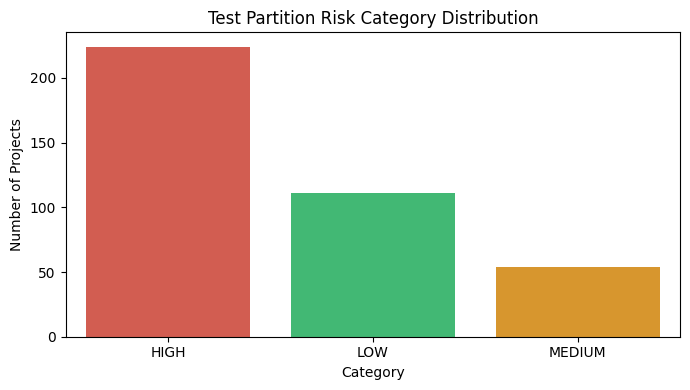

In [4]:
dist_summary = df_eval["risk_category"].value_counts()
dist_pct = df_eval["risk_category"].value_counts(normalize=True) * 100

df_dist_table = pd.DataFrame({
    "Category": dist_summary.index,
    "Count": dist_summary.values,
    "Percentage": np.round(dist_pct.values, 2)
})
display(df_dist_table)

plt.figure(figsize=(7, 4))
sns.barplot(data=df_dist_table, x="Category", y="Count", palette={"LOW": "#2ecc71", "MEDIUM": "#f39c12", "HIGH": "#e74c3c"})
plt.title("Test Partition Risk Category Distribution")
plt.ylabel("Number of Projects")
plt.tight_layout()
plt.show()


### 4. Initialize SHAP TreeExplainer & Compute Shapley Matrix

In [5]:
explainer = get_tree_explainer(model)
shap_values = explainer.shap_values(X_test)

print(f"SHAP Matrix Shape: {shap_values.shape}")
print(f"Base Expected Value: {explainer.expected_value:.4f}")


SHAP Matrix Shape: (389, 97)
Base Expected Value: 0.4800


### 5. Global SHAP Summary Plot (Feature Impacts & Directionality)

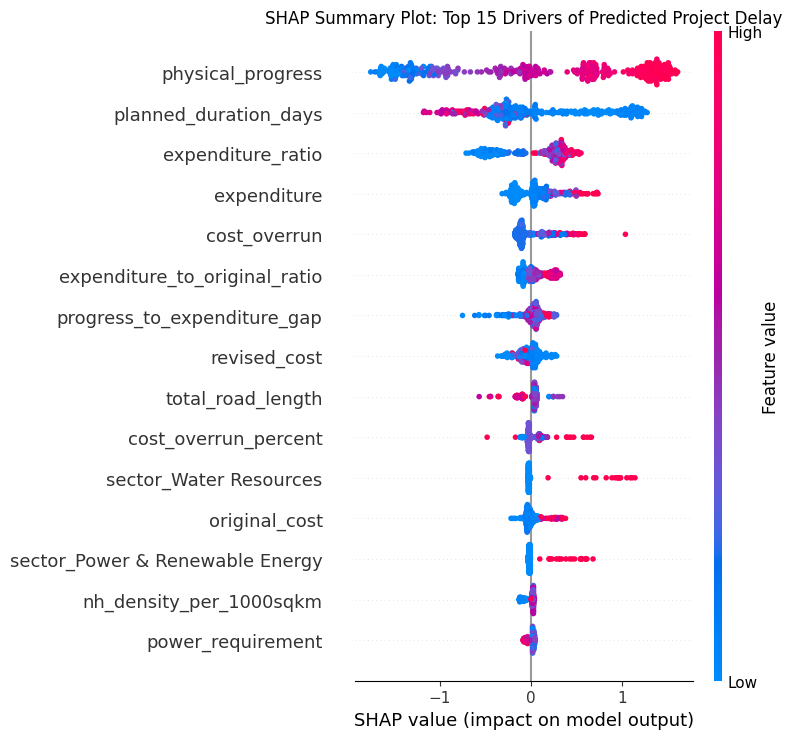

In [6]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title("SHAP Summary Plot: Top 15 Drivers of Predicted Project Delay", fontsize=12)
plt.tight_layout()
plt.show()


### 6. Mean Absolute SHAP Feature Importance Ranking

Top 10 Global SHAP Features:


,feature,mean_abs_shap
0,physical_progress,0.976082
1,planned_duration_days,0.520486
2,expenditure_ratio,0.338887
3,expenditure,0.174214
4,cost_overrun,0.156241
5,expenditure_to_original_ratio,0.103449
6,progress_to_expenditure_gap,0.090192
7,revised_cost,0.078843
8,total_road_length,0.073258
9,cost_overrun_percent,0.064209


C:\Users\RABIYA BUSHRA\AppData\Local\Temp\ipykernel_27692\4166471314.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_shap_imp.head(15), x="mean_abs_shap", y="feature", palette="rocket")


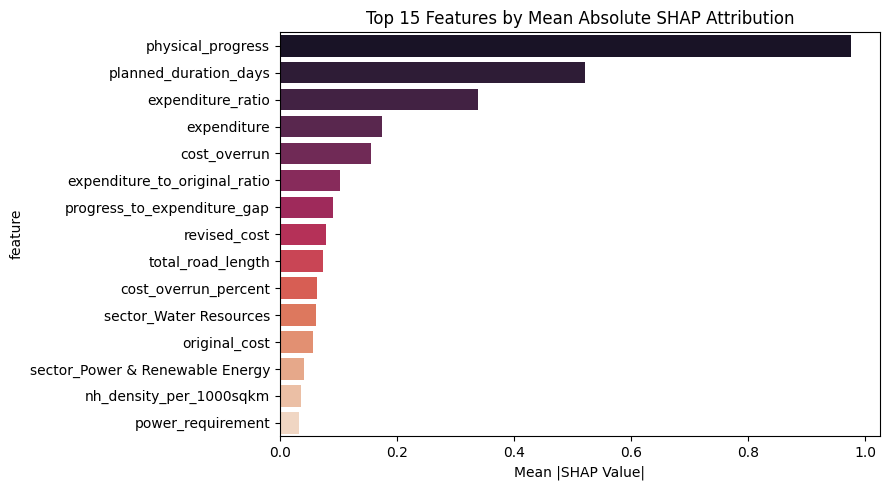

In [7]:
mean_abs = np.abs(shap_values).mean(axis=0)
df_shap_imp = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": mean_abs
}).sort_values(by="mean_abs_shap", ascending=False).reset_index(drop=True)

print("Top 10 Global SHAP Features:")
display(df_shap_imp.head(10))

plt.figure(figsize=(9, 5))
sns.barplot(data=df_shap_imp.head(15), x="mean_abs_shap", y="feature", palette="rocket")
plt.title("Top 15 Features by Mean Absolute SHAP Attribution")
plt.xlabel("Mean |SHAP Value|")
plt.tight_layout()
plt.show()


### 7. Local Project Explanation & Non-Causal Narrative Synthesis

In [8]:
sample_project = df_master.iloc[0].to_dict()
explanation = explain_single_project(sample_project, model, preprocessor, explainer, list(X_test.columns))

print(f"Project ID:       {explanation['project_id']}")
print(f"Project Name:     {explanation['project_name']}")
print(f"Risk Score:       {explanation['risk_score']} / 100")
print(f"Risk Category:    {explanation['risk_category']}")
print(f"Delay Probability:{explanation['delay_probability']}")
print("\nTop Positive Factors (Increasing Delay Risk):")
for f in explanation['top_risk_increasing_factors'][:3]:
    print(f"  - {f['feature']}: +{f['shap_value']:.4f}")

print("\nTop Negative Factors (Mitigating Delay Risk):")
for f in explanation['top_risk_reducing_factors'][:2]:
    print(f"  - {f['feature']}: {f['shap_value']:.4f}")

print("\nHuman-Readable Explanations:")
for n in explanation['narrative_explanations']:
    print(f"  • {n}")


Project ID:       612786
Project Name:     Construction of New Domestic Terminal Building Building and miscellaneous works including maintenance, operations and AICMC at Kadapa Airport
Risk Score:       88.62 / 100
Risk Category:    HIGH
Delay Probability:0.8862

Top Positive Factors (Increasing Delay Risk):
  - planned_duration_days: +1.1809
  - expenditure_ratio: +0.2935
  - avg_household_size: +0.0657

Top Negative Factors (Mitigating Delay Risk):
  - cost_overrun: -0.1305
  - sector_Road Transport & Highways: -0.0440

Human-Readable Explanations:
  • Planned Duration Days is strongly contributing toward higher predicted project delay risk.
  • Expenditure Ratio is strongly contributing toward higher predicted project delay risk.
  • Avg Household Size is contributing toward higher predicted project delay risk.
  • Cost Overrun is contributing toward lowering the predicted delay risk.
  • Sector: Road Transport & Highways is contributing toward lowering the predicted delay risk.


### 8. Individual Project Attribution Plot

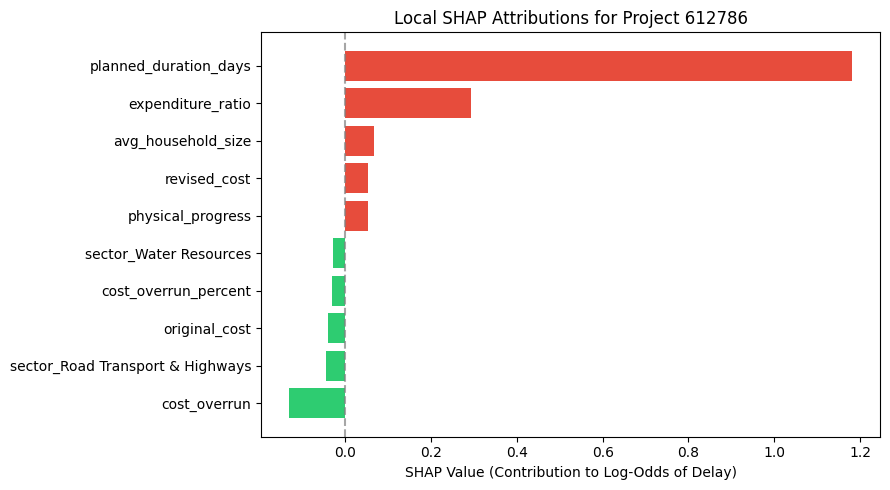

In [9]:
pos_df = pd.DataFrame(explanation["top_risk_increasing_factors"])
neg_df = pd.DataFrame(explanation["top_risk_reducing_factors"])
combo_df = pd.concat([pos_df, neg_df]).sort_values(by="shap_value")

plt.figure(figsize=(9, 5))
colors_bar = ["#e74c3c" if sv > 0 else "#2ecc71" for sv in combo_df["shap_value"]]
plt.barh(combo_df["feature"], combo_df["shap_value"], color=colors_bar)
plt.axvline(0, color="gray", linestyle="--", alpha=0.7)
plt.title(f"Local SHAP Attributions for Project {explanation['project_id']}")
plt.xlabel("SHAP Value (Contribution to Log-Odds of Delay)")
plt.tight_layout()
plt.show()


### 9. Validation: SHAP Additivity & Consistency Audit

In [10]:
base_val = explainer.expected_value
sample_shap_sum = shap_values[0].sum()
total_log_odds = base_val + sample_shap_sum

# Model raw margin output
raw_margin = model.predict(X_test.iloc[[0]], output_margin=True)[0]

print("SHAP Additivity Verification:")
print(f"  Base Expected Value:    {base_val:.6f}")
print(f"  Sum of SHAP Values:     {sample_shap_sum:.6f}")
print(f"  Reconstructed Margin:   {total_log_odds:.6f}")
print(f"  Actual XGBoost Margin:  {raw_margin:.6f}")
print(f"  Absolute Discrepancy:   {abs(total_log_odds - raw_margin):.2e}")
assert abs(total_log_odds - raw_margin) < 1e-4, "Additivity check failed!"
print(">> PASSED: SHAP values strictly preserve local mathematical additivity.")


SHAP Additivity Verification:
  Base Expected Value:    0.479980
  Sum of SHAP Values:     -1.849844
  Reconstructed Margin:   -1.369864
  Actual XGBoost Margin:  -1.369864
  Absolute Discrepancy:   7.15e-07
>> PASSED: SHAP values strictly preserve local mathematical additivity.
